In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Cropping2D,
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

current_dir = os.getcwd()
if current_dir.endswith("notebooks"):
    os.chdir("..")

# ARAH KE DATA 80:10:10
TRAIN_DIR = os.path.join("data", "processed (80-10-10)", "train")
VAL_DIR = os.path.join("data", "processed (80-10-10)", "val")
TEST_DIR = os.path.join("data", "processed (80-10-10)", "test")

IMG_HEIGHT = 588
IMG_WIDTH = 420
BATCH_SIZE = 16
NUM_CLASSES = 10

train_datagen = ImageDataGenerator(rescale=1.0 / 255, brightness_range=[0.8, 1.2])
val_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

class_weights = compute_class_weight(
    "balanced", classes=np.unique(train_generator.classes), y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

Found 1837 images belonging to 10 classes.
Found 226 images belonging to 10 classes.
Found 237 images belonging to 10 classes.


In [2]:
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Cropping2D dipertahankan sesuai arsitektur awal baseline
top_crop = int(IMG_HEIGHT * 0.85)
x = Cropping2D(cropping=((top_crop, 0), (0, int(IMG_WIDTH * 0.70))))(inputs)

x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)

x = Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=inputs, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
)

os.makedirs("models", exist_ok=True)
model.save(os.path.join("models", "cnn_baseline_801010.keras"))

Epoch 1/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.1383 - loss: 2.7873 - val_accuracy: 0.1018 - val_loss: 5.3330 - learning_rate: 0.0010
Epoch 2/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 76s 658ms/step - accuracy: 0.1971 - loss: 2.1505 - val_accuracy: 0.1018 - val_loss: 4.8861 - learning_rate: 0.0010
Epoch 3/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 73s 632ms/step - accuracy: 0.2226 - loss: 2.0677 - val_accuracy: 0.2035 - val_loss: 2.1311 - learning_rate: 0.0010
Epoch 4/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 51s 441ms/step - accuracy: 0.2341 - loss: 2.0143 - val_accuracy: 0.4159 - val_loss: 1.8908 - learning_rate: 0.0010
Epoch 5/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 513ms/step - accuracy: 0.2537 - loss: 1.9969 - val_accuracy: 0.4292 - val_loss: 1.8309 - learning_rate: 0.0010
Epoch 6/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 361ms/step - accuracy: 0.2319 - loss: 2.0168 - val_accuracy: 0.4071 - val_loss: 1.9001 - learning_rate: 0.0010
Epoch 7/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 64s 554ms/step - accuracy: 0.219

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 393ms/step - accuracy: 0.4262 - loss: 1.7771

Akurasi Baseline Test Set (80:10:10): 42.62%

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step


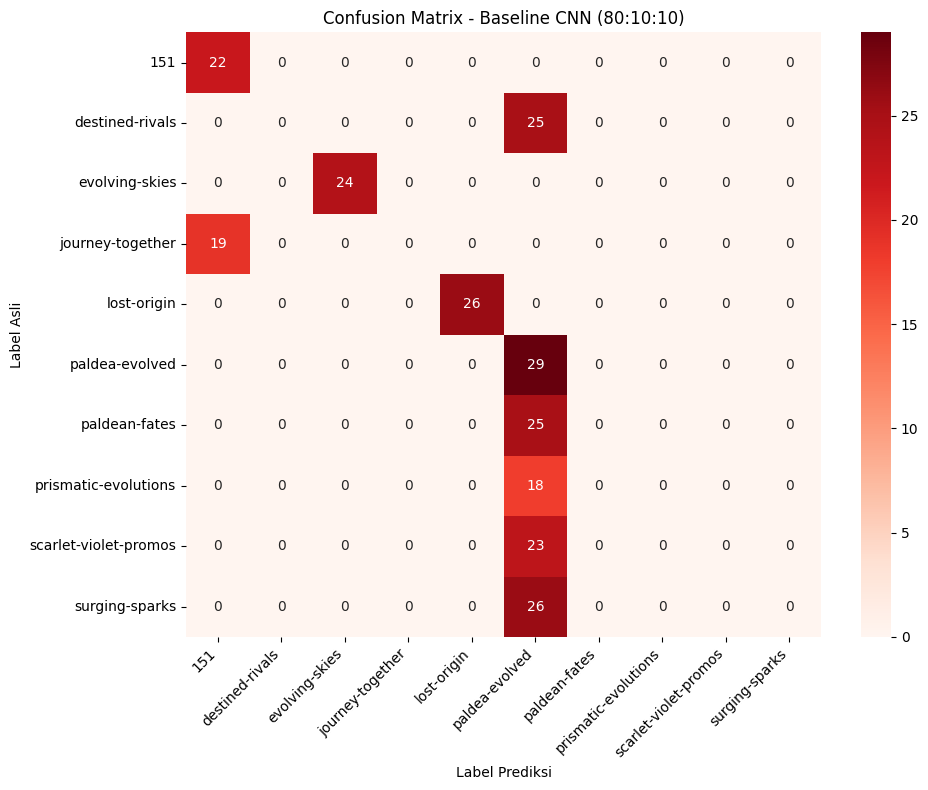

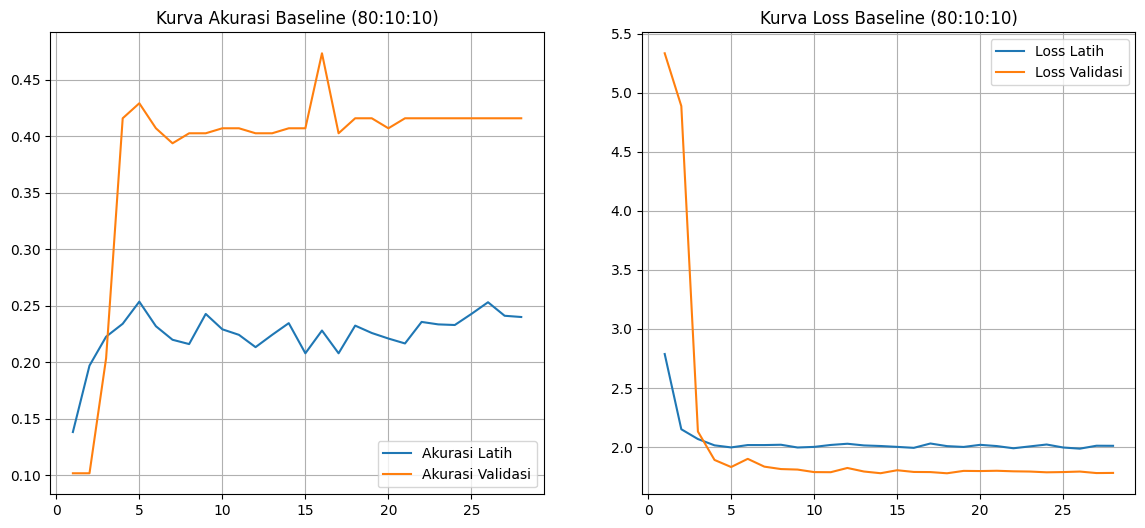

In [3]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nAkurasi Baseline Test Set (80:10:10): {test_acc * 100:.2f}%\n")

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

os.makedirs("reports", exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix - Baseline CNN (80:10:10)")
plt.ylabel("Label Asli")
plt.xlabel("Label Prediksi")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join("reports", "cm_baseline_801010.png"))
plt.show()

# Learning Curves
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Akurasi Latih")
plt.plot(epochs_range, val_acc, label="Akurasi Validasi")
plt.title("Kurva Akurasi Baseline (80:10:10)")
plt.legend(loc="lower right")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Loss Latih")
plt.plot(epochs_range, val_loss, label="Loss Validasi")
plt.title("Kurva Loss Baseline (80:10:10)")
plt.legend(loc="upper right")
plt.grid(True)

plt.savefig(os.path.join("reports", "lc_baseline_801010.png"))
plt.show()